In [1]:
import json

import logomaker as lm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyliftover
import seaborn as sns
from pyfaidx import Fasta
from scipy.stats import chi2_contingency

from analysis_functions import (
                        calculate_chi2_p_values,
                        filter_and_convert_to_list,
                        check_ref,
                        get_codon_info,
                        get_context
                    )

## 1. Separate variants by pathogenicity value

Create dataframes for pathogenic/benign variants based on frequency.

* **pathogenic**  
 Cutoff in AC < 2. Additionally, intersect with the options in ClinVar and add pathogenic/likely pathogenic variants that are missing in GnomAD v.4, but are in ClinVar.

* **benign**  
 AC cut-off >= 2 (according to recent ACGS guidelines, BS2 criterion). In this case, we may have many autosomal recessive variants left, so let’s remove them. To do this, compare the resulting dataframe with benign ClinVar variants and remove all intersections with registered P/LP variants.

In [2]:
nmd_undergo_df = pd.read_csv("data/lof_final_with_loeuf_pext_nmd_undergo.csv")

In [3]:
nmd_undergo_df.shape

(21116, 31)

In [4]:
nmd_undergo_df['BIOTYPE'].value_counts()

BIOTYPE
protein_coding    21116
Name: count, dtype: int64

In [5]:
pat_nmd_undergo = nmd_undergo_df.query('AC < 2')

In [6]:
pat_nmd_undergo

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,1825438,rs867938404,G,A,1,stop_gained,HIGH,GNB1,ENSG00000078369,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0156402737047898,0.145,0.966547,NO
1,chr1,2024966,NaN,C,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.000000,NO
2,chr1,2024966,NaN,C,G,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.000000,NO
3,chr1,2024993,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0883002207505519,0.245,1.000000,NO
4,chr1,2025553,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.209713024282561,0.245,1.000000,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21107,chr22,50720328,NaN,C,A,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.434494195688226,0.123,1.000000,NO
21108,chr22,50720377,NaN,C,A,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.444651741293532,0.123,1.000000,NO
21109,chr22,50720479,NaN,T,A,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.465796019900498,0.123,1.000000,NO
21111,chr22,50720939,NaN,G,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.561152570480929,0.123,1.000000,NO


In [7]:
ben_nmd_undergo = nmd_undergo_df.query('AC >= 2')

In [8]:
ben_nmd_undergo

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
5,chr1,2025660,NaN,C,A,2,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.288447387785136,0.245,1.000000,NO
8,chr1,2028164,rs1441225021,C,G,3,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.414275202354673,0.245,1.000000,NO
11,chr1,2029236,rs1405824159,C,T,5,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.601177336276674,0.245,1.000000,NO
12,chr1,2228818,rs1225111926,C,T,2,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0237768632830361,0.194,0.950938,NO
25,chr1,2509920,rs1424097228,G,A,3,stop_gained,HIGH,PANK4,ENSG00000157881,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.882859603789836,0.304,0.694764,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21105,chr22,50720238,NaN,C,A,3,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.415837479270315,0.123,1.000000,NO
21110,chr22,50720534,NaN,G,T,2,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.477197346600332,0.123,1.000000,NO
21113,chr22,50721521,NaN,G,T,5,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123,1.000000,NO
21114,chr22,50721995,NaN,G,T,2,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123,1.000000,NO


In [9]:
ben_nmd_undergo.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape'],
      dtype='object')

In [10]:
pat_nmd_undergo['AC'].value_counts()  # 1    1669

AC
1    15868
Name: count, dtype: int64

In [11]:
ben_nmd_undergo['AC'].value_counts()  # from 2 to 79

AC
2       2794
3       1067
4        541
5        300
6        156
7        102
8         65
9         47
10        34
11        24
12        23
13        15
16        12
14        10
19         6
15         6
24         4
22         4
26         3
32         3
21         3
20         3
25         2
23         2
17         2
18         1
111        1
36         1
229        1
118        1
28         1
89         1
71         1
1104       1
74         1
51         1
233        1
44         1
57         1
108        1
284        1
35         1
53         1
55         1
50         1
Name: count, dtype: int64

### Remove all pathogenic Clinvar variants from benign dataframe

Merge `clinvar_nmd_under_df` and `ben_nmd_undergo` dataframes, remove all intersections by `CHROM`, `POS`, `REF`, `ALT`, and then remove the remainder of `clinvar_nmd_under_df` (i.e. remove all rows that do not have an empty `CLNSIG` column).

In [12]:
clinvar_nmd_under_df = pd.read_csv("data/clinvar_nmd_undergo_df.csv")
# clinvar_nmd_under = clinvar_nmd_under_df.rename(columns={'Feature': 'Canonical_transcript'})

In [13]:
clinvar_nmd_under_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL,LOEUF,pext,NMD_escape
0,chr1,1790454,986264,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,SO:0001587|nonsense,...,640.0,214.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.951698,NO
1,chr1,1815771,3281766,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001627|intron_variant",...,188.0,63.0,W/*,tGg/tAg,-1.0,NaN,YES,0.145,0.966547,NO
2,chr1,1825399,1433729,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001623|5_prime_UTR_var...",...,55.0,19.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.966547,NO
3,chr1,3385247,1029845,C,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,534.0,178.0,C/*,tgC/tgA,1.0,NaN,YES,0.187,0.848889,NO
4,chr1,3385272,3340802,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,559.0,187.0,Q/*,Cag/Tag,1.0,NaN,YES,0.187,0.848889,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7097,chr22,41176400,183678,C,T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,4933.0,1645.0,R/*,Cga/Tga,1.0,NaN,YES,0.099,1.000000,NO
7098,chr22,50447442,1301645,G,C,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5463.0,1821.0,Y/*,taC/taG,-1.0,NaN,YES,0.265,0.771752,NO
7099,chr22,50448330,3644969,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5266.0,1756.0,Q/*,Cag/Tag,-1.0,NaN,YES,0.265,0.771752,NO
7100,chr22,50448592,2018999,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5102.0,1701.0,W/*,tGg/tAg,-1.0,NaN,YES,0.265,0.771752,NO


In [14]:
clinvar_nmd_under_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'CLNREVSTAT', 'CLNSIG', 'CLNVC',
       'GENEINFO', 'MC', 'Consequence', 'SYMBOL', 'Gene', 'Feature_type',
       'Feature', 'BIOTYPE', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'FLAGS',
       'CANONICAL', 'LOEUF', 'pext', 'NMD_escape'],
      dtype='object')

In [15]:
merged_clinvar_and_ben = pd.concat([ben_nmd_undergo, clinvar_nmd_under_df], ignore_index=True)
merged_clinvar_and_ben

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_info,LOEUF,pext,NMD_escape,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,Feature_type
0,chr1,2025660,NaN,C,A,2.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,PERCENTILE:0.288447387785136,0.245,1.000000,NO,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,2028164,rs1441225021,C,G,3.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,PERCENTILE:0.414275202354673,0.245,1.000000,NO,NaN,NaN,NaN,NaN,NaN,NaN
2,chr1,2029236,rs1405824159,C,T,5.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,PERCENTILE:0.601177336276674,0.245,1.000000,NO,NaN,NaN,NaN,NaN,NaN,NaN
3,chr1,2228818,rs1225111926,C,T,2.0,stop_gained,HIGH,SKI,ENSG00000157933,...,PERCENTILE:0.0237768632830361,0.194,0.950938,NO,NaN,NaN,NaN,NaN,NaN,NaN
4,chr1,2509920,rs1424097228,G,A,3.0,stop_gained,HIGH,PANK4,ENSG00000157881,...,PERCENTILE:0.882859603789836,0.304,0.694764,NO,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12345,chr22,41176400,183678,C,T,NaN,stop_gained,NaN,EP300,ENSG00000100393,...,NaN,0.099,1.000000,NO,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,Transcript
12346,chr22,50447442,1301645,G,C,NaN,stop_gained,NaN,SBF1,ENSG00000100241,...,NaN,0.265,0.771752,NO,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,Transcript
12347,chr22,50448330,3644969,G,A,NaN,stop_gained,NaN,SBF1,ENSG00000100241,...,NaN,0.265,0.771752,NO,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,Transcript
12348,chr22,50448592,2018999,C,T,NaN,stop_gained,NaN,SBF1,ENSG00000100241,...,NaN,0.265,0.771752,NO,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,Transcript


In [16]:
merged_clinvar_and_ben.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape', 'CLNREVSTAT', 'CLNSIG', 'CLNVC', 'GENEINFO', 'MC',
       'Feature_type'],
      dtype='object')

In [17]:
# remove duplicates
ben_nmd_undergo_filtered = merged_clinvar_and_ben.drop_duplicates(subset=['CHROM', 'POS', 'REF', 'ALT'], keep=False)

In [18]:
# remove the Clinvar df
ben_nmd_undergo_filtered = ben_nmd_undergo_filtered[~ben_nmd_undergo_filtered['CLNSIG'].notna()]

In [19]:
ben_nmd_undergo_filtered.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape', 'CLNREVSTAT', 'CLNSIG', 'CLNVC', 'GENEINFO', 'MC',
       'Feature_type'],
      dtype='object')

In [20]:
pat_nmd_undergo.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info', 'LOEUF', 'pext',
       'NMD_escape'],
      dtype='object')

Remove unnecessary columns left after Clinvar.

In [21]:
# ben_nmd_undergo_filtered = ben_nmd_undergo_filtered.drop(columns=['ID', 'CLNSIG', 'CLNVC', 'GENEINFO', 'CLNREVSTAT', 'MC', 'SYMBOL', 
#                                                 'Gene', 'Feature_type', 'BIOTYPE', 'CANONICAL'])
ben_nmd_undergo_filtered = ben_nmd_undergo_filtered.drop(columns=['CLNSIG', 'CLNVC', 'GENEINFO', 'MC', 'CLNREVSTAT', 'Feature_type'])
ben_nmd_undergo_filtered

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,2025660,NaN,C,A,2.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.288447387785136,0.245,1.000000,NO
1,chr1,2028164,rs1441225021,C,G,3.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.414275202354673,0.245,1.000000,NO
2,chr1,2029236,rs1405824159,C,T,5.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.601177336276674,0.245,1.000000,NO
3,chr1,2228818,rs1225111926,C,T,2.0,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0237768632830361,0.194,0.950938,NO
4,chr1,2509920,rs1424097228,G,A,3.0,stop_gained,HIGH,PANK4,ENSG00000157881,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.882859603789836,0.304,0.694764,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,chr22,50720238,NaN,C,A,3.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.415837479270315,0.123,1.000000,NO
5244,chr22,50720534,NaN,G,T,2.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.477197346600332,0.123,1.000000,NO
5245,chr22,50721521,NaN,G,T,5.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123,1.000000,NO
5246,chr22,50721995,NaN,G,T,2.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123,1.000000,NO


In [22]:
ben_nmd_undergo_filtered.columns == pat_nmd_undergo.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [23]:
ben_nmd_undergo_filtered.shape

(4909, 31)

Before filtering:

In [24]:
ben_nmd_undergo.shape

(5248, 31)

**The dataframe with benign variants is ready.**

In [25]:
pat_nmd_undergo_filtered = pat_nmd_undergo.copy()

**The dataframe with pathogenic variants is ready.**

## 2. Balance dataframes

In both dataframes, we will leave only those genes that are found in both `ben_nmd_undergo_filtered` and `pat_nmd_undergo_filtered`, and also equalize the number of variants in each gene.

In [26]:
ben_nmd_undergo_filtered

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,2025660,NaN,C,A,2.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.288447387785136,0.245,1.000000,NO
1,chr1,2028164,rs1441225021,C,G,3.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.414275202354673,0.245,1.000000,NO
2,chr1,2029236,rs1405824159,C,T,5.0,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.601177336276674,0.245,1.000000,NO
3,chr1,2228818,rs1225111926,C,T,2.0,stop_gained,HIGH,SKI,ENSG00000157933,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0237768632830361,0.194,0.950938,NO
4,chr1,2509920,rs1424097228,G,A,3.0,stop_gained,HIGH,PANK4,ENSG00000157881,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.882859603789836,0.304,0.694764,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,chr22,50720238,NaN,C,A,3.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.415837479270315,0.123,1.000000,NO
5244,chr22,50720534,NaN,G,T,2.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.477197346600332,0.123,1.000000,NO
5245,chr22,50721521,NaN,G,T,5.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123,1.000000,NO
5246,chr22,50721995,NaN,G,T,2.0,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123,1.000000,NO


In [27]:
unique_genes_ben = ben_nmd_undergo_filtered['SYMBOL'].astype(str).unique()
unique_genes_pat = pat_nmd_undergo_filtered['SYMBOL'].astype(str).unique()
intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))


Unique genes in pat dataframe: 1933
Unique genes in ben dataframe: 1350
Intersected genes: 1315


In [28]:
common_genes = set(unique_genes_ben) & set(unique_genes_pat)

ben_nmd_undergo_filtered = ben_nmd_undergo_filtered[ben_nmd_undergo_filtered['SYMBOL'].isin(common_genes)]
pat_nmd_undergo_filtered = pat_nmd_undergo_filtered[pat_nmd_undergo_filtered['SYMBOL'].isin(common_genes)]

In [29]:
unique_genes_pat = pat_nmd_undergo_filtered['SYMBOL'].unique()
unique_genes_ben = ben_nmd_undergo_filtered['SYMBOL'].unique()

intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))

Unique genes in pat dataframe: 1315
Unique genes in ben dataframe: 1315
Intersected genes: 1315


In [30]:
count_pat = pat_nmd_undergo_filtered['SYMBOL'].value_counts()
count_ben = ben_nmd_undergo_filtered['SYMBOL'].value_counts()

min_counts = pd.concat([count_pat, count_ben], axis=1).min(axis=1)

pat_nmd_undergo_final = pd.concat([
    pat_nmd_undergo_filtered[pat_nmd_undergo_filtered['SYMBOL'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])

ben_nmd_undergo_final = pd.concat([
    ben_nmd_undergo_filtered[ben_nmd_undergo_filtered['SYMBOL'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])


In [31]:
pat_nmd_undergo_final.shape == ben_nmd_undergo_final.shape

True

In [32]:
pat_nmd_undergo_final.shape

(4761, 31)

In [33]:
ben_nmd_undergo_final.shape

(4761, 31)

In [34]:
pat_nmd_undergo_final['SYMBOL'].nunique() == ben_nmd_undergo_final['SYMBOL'].nunique()

True

In [35]:
pat_nmd_undergo_final['SYMBOL'].value_counts().sum() == ben_nmd_undergo_final['SYMBOL'].value_counts().sum()

np.True_

In [36]:
pat_nmd_undergo_final['SYMBOL'].nunique()

1315

In [37]:
ben_nmd_undergo_final['SYMBOL'].nunique()

1315

In [38]:
pat_nmd_undergo_final.shape

(4761, 31)

In [39]:
ben_nmd_undergo_final.shape

(4761, 31)

Dataframes are now balanced by genes and number of variants.

## 3. Get sequence context

Write the context in the corresponding column of the dataframe.

File `gencode.v47.transcripts.fa.gz` can be downloaded from the GENCODE database (https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_47/gencode.v47.transcripts.fa.gz).

In [40]:
ben_nmd_undergo_final.dtypes

CHROM                object
POS                   int64
ID                   object
REF                  object
ALT                  object
AC                  float64
Consequence          object
IMPACT               object
SYMBOL               object
Gene                 object
Feature              object
BIOTYPE              object
EXON                 object
INTRON              float64
cDNA_position       float64
CDS_position        float64
Protein_position    float64
Amino_acids          object
Codons               object
ALLELE_NUM          float64
STRAND              float64
FLAGS               float64
VARIANT_CLASS        object
CANONICAL            object
LoF                  object
LoF_filter          float64
LoF_flags           float64
LoF_info             object
LOEUF               float64
pext                float64
NMD_escape           object
dtype: object

In [41]:
ben_nmd_undergo_final['Codons']

387     Cga/Tga
404     Cga/Tga
402     Cga/Tga
388     tCa/tAa
395     Cga/Tga
         ...   
3214    Cga/Tga
3245    Cag/Tag
420     Cga/Tga
4945    Cga/Tga
298     Cga/Tga
Name: Codons, Length: 4761, dtype: object

In [42]:
ben_nmd_undergo_final['cDNA_position'] = ben_nmd_undergo_final['cDNA_position'].astype(int)

In [43]:
pat_nmd_undergo_final['cDNA_position'] = pat_nmd_undergo_final['cDNA_position'].astype(int)

In [44]:
transcript_fasta = Fasta("data/gencode.v47.transcripts.fa.gz", key_function = lambda x: x.split('.')[0])

In [45]:
get_context(ben_nmd_undergo_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [46]:
get_context(pat_nmd_undergo_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [47]:
# pat_nmd_undergo_final['Strand'] = pat_nmd_undergo_final.apply(check_ref, axis=1, transcript_fasta=transcript_fasta)
# pat_nmd_undergo_final['Strand'].value_counts()

In [48]:
# ben_nmd_undergo_final['Strand'] = ben_nmd_undergo_final.apply(check_ref, axis=1, transcript_fasta=transcript_fasta)
# ben_nmd_undergo_final['Strand'].value_counts()

In [49]:
# pat_nmd_undergo_final = pat_nmd_undergo_final[pat_nmd_undergo_final['Strand'] != 'Not_defined']
# ben_nmd_undergo_final = ben_nmd_undergo_final[ben_nmd_undergo_final['Strand'] != 'Not_defined']

## 4. Get variant codons information

In [50]:
ben_nmd_undergo_final['Codons']

387     Cga/Tga
404     Cga/Tga
402     Cga/Tga
388     tCa/tAa
395     Cga/Tga
         ...   
3214    Cga/Tga
3245    Cag/Tag
420     Cga/Tga
4945    Cga/Tga
298     Cga/Tga
Name: Codons, Length: 4761, dtype: object

Получим информацию о позиции в кодоне

In [51]:
def get_codon_position(codon_change):
    codon = codon_change.split('/')[0]  # первый кодон (до слэша)
    for i, base in enumerate(codon, start=1):
        if base.isupper():
            return i
    return None  # если вдруг нет заглавной буквы

In [52]:
ben_nmd_undergo_final['Codon_position'] = ben_nmd_undergo_final['Codons'].apply(get_codon_position)

In [53]:
ben_nmd_undergo_final['Codon_position'].value_counts()

Codon_position
1    3764
3     505
2     492
Name: count, dtype: int64

In [54]:
pat_nmd_undergo_final['Codon_position'] = pat_nmd_undergo_final['Codons'].apply(get_codon_position)

In [55]:
pat_nmd_undergo_final['Codon_position'].value_counts()

Codon_position
1    2970
3     969
2     822
Name: count, dtype: int64

Получим информацию о начальном кодоне и получаемом стоп-кодоне

In [56]:
def get_initial_codon(codon_change):
    return codon_change.split('/')[0].upper()

def get_stop_codon(codon_change):
    return codon_change.split('/')[1].upper()

In [57]:
ben_nmd_undergo_final['Initial_Codon'] = ben_nmd_undergo_final['Codons'].apply(get_initial_codon)
ben_nmd_undergo_final['Stop_Codon'] = ben_nmd_undergo_final['Codons'].apply(get_stop_codon)

In [58]:
pat_nmd_undergo_final['Initial_Codon'] = pat_nmd_undergo_final['Codons'].apply(get_initial_codon)
pat_nmd_undergo_final['Stop_Codon'] = pat_nmd_undergo_final['Codons'].apply(get_stop_codon)

Divide dataframes depending on codon position.

In [62]:
ben_nmd_undergo_final_1 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 1].copy()
ben_nmd_undergo_final_2 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 2].copy()
ben_nmd_undergo_final_3 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 3].copy()

In [63]:
pat_nmd_undergo_final_1 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 1].copy()
pat_nmd_undergo_final_2 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 2].copy()
pat_nmd_undergo_final_3 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 3].copy()

## 6. Build a sequence logo

Вытягиваем последовательности контекста, чтобы можно было построить графики по ним

In [64]:
filtered_context_ben_1 = filter_and_convert_to_list(ben_nmd_undergo_final_1['Context'])
filtered_context_ben_2 = filter_and_convert_to_list(ben_nmd_undergo_final_2['Context'])
filtered_context_ben_3 = filter_and_convert_to_list(ben_nmd_undergo_final_3['Context'])

In [65]:
filtered_context_pat_1 = filter_and_convert_to_list(pat_nmd_undergo_final_1['Context'])
filtered_context_pat_2 = filter_and_convert_to_list(pat_nmd_undergo_final_2['Context'])
filtered_context_pat_3 = filter_and_convert_to_list(pat_nmd_undergo_final_3['Context'])

In [66]:
custom_colors = {
    'A': '#E55D3F',  # red
    'C': '#53B943',  # green
    'G': '#4F64C7',  # blue
    'T': '#F5B846'   # yellow
}

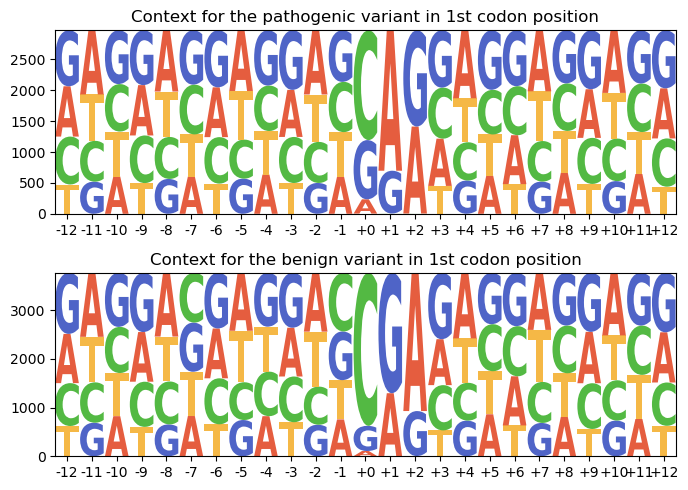

In [67]:
counts_mat_pat_1 = lm.alignment_to_matrix(filtered_context_pat_1)
counts_mat_ben_1 = lm.alignment_to_matrix(filtered_context_ben_1)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_1, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 1st codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_1, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 1st codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/1st_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

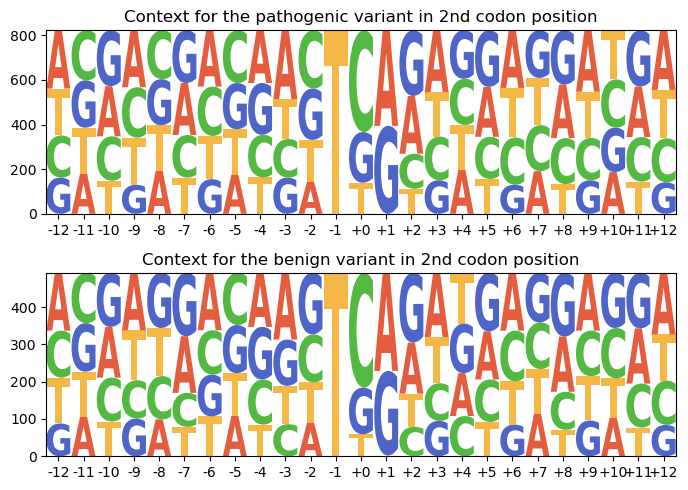

In [68]:
counts_mat_pat_2 = lm.alignment_to_matrix(filtered_context_pat_2)
counts_mat_ben_2 = lm.alignment_to_matrix(filtered_context_ben_2)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_2, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 2nd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_2, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 2nd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/2nd_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

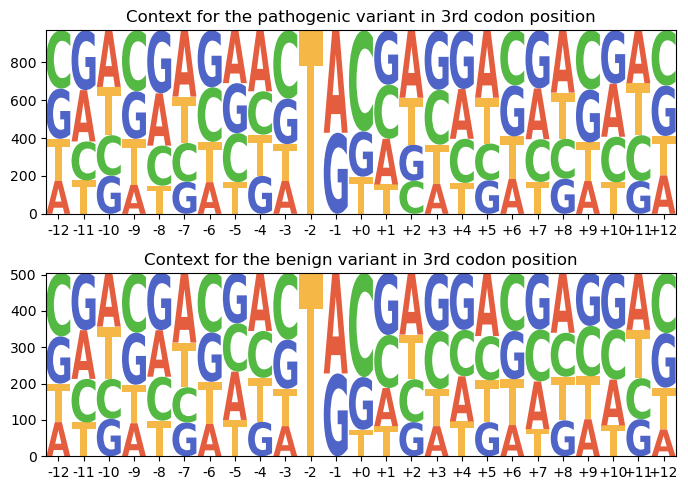

In [69]:
counts_mat_pat_3 = lm.alignment_to_matrix(filtered_context_pat_3)
counts_mat_ben_3 = lm.alignment_to_matrix(filtered_context_ben_3)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_3, color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 3rd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_3, color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 3rd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/3rd_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

## 7. Statistical comparison of positions in contexts

Calculate chi-squares for each position when comparing two matrices (for pathogenic and benign contexts).

In [70]:
chi2_values_1, p_values_1 = calculate_chi2_p_values(filtered_context_ben_1, filtered_context_pat_1)
for i, (chi2, p_value) in enumerate(zip(chi2_values_1, p_values_1)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 9.61156396450959, p-value = 0.06929266136195299
Position 1: Chi-square = 0.738893539249154, p-value = 0.8640198707699742
Position 2: Chi-square = 2.971465359402726, p-value = 0.5500633505970381
Position 3: Chi-square = 4.867650753858643, p-value = 0.3786435900016817
Position 4: Chi-square = 3.5626003842874443, p-value = 0.5115151849232402
Position 5: Chi-square = 7.662125160483308, p-value = 0.133839692028054
Position 6: Chi-square = 1.315771697757183, p-value = 0.7884688927654337
Position 7: Chi-square = 3.2836215930968176, p-value = 0.5146010693651615
Position 8: Chi-square = 1.0525045134323356, p-value = 0.8214065056957622
Position 9: Chi-square = 7.0780031414632685, p-value = 0.15784697727002056
Position 10: Chi-square = 16.32959419825997, p-value = 0.003768548114094324
Position 11: Chi-square = 18.808405675755015, p-value = 0.001497519655079355
Position 12: Chi-square = 469.8712579917128, p-value = 1.3440713734005665e-100
Position 13: Chi-square = 1195.410

In [71]:
chi2_values_2, p_values_2 = calculate_chi2_p_values(filtered_context_ben_2, filtered_context_pat_2)
for i, (chi2, p_value) in enumerate(zip(chi2_values_2, p_values_2)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 1.458631721317118, p-value = 1.0
Position 1: Chi-square = 0.09587461870904926, p-value = 1.0
Position 2: Chi-square = 0.24071908775718046, p-value = 1.0
Position 3: Chi-square = 9.473098290856278, p-value = 0.2635581071689851
Position 4: Chi-square = 5.667278974015456, p-value = 0.358246845750833
Position 5: Chi-square = 9.541785556908017, p-value = 0.2635581071689851
Position 6: Chi-square = 3.681962127631998, p-value = 0.7447941740844422
Position 7: Chi-square = 0.46319533505288535, p-value = 1.0
Position 8: Chi-square = 1.3839426010335807, p-value = 1.0
Position 9: Chi-square = 6.456075783588198, p-value = 0.3264676983286004
Position 10: Chi-square = 6.525458159898221, p-value = 0.3264676983286004
Position 11: Chi-square = nan, p-value = 1.0
Position 12: Chi-square = 8.542091626920469, p-value = 0.2635581071689851
Position 13: Chi-square = nan, p-value = 1.0
Position 14: Chi-square = 7.3891947505480085, p-value = 0.30237458749907714
Position 15: Chi-square =

In [72]:
chi2_values_3, p_values_3 = calculate_chi2_p_values(filtered_context_ben_3, filtered_context_pat_3)
for i, (chi2, p_value) in enumerate(zip(chi2_values_3, p_values_3)):
    print(f"Position {i}: Chi-square = {chi2}, p-value = {p_value}")

Position 0: Chi-square = 1.7024760537607841, p-value = 0.9857644260946553
Position 1: Chi-square = 1.3811000620655665, p-value = 0.9857644260946553
Position 2: Chi-square = 0.8891633737354259, p-value = 0.9857644260946553
Position 3: Chi-square = 4.094845407713169, p-value = 0.8802092328943742
Position 4: Chi-square = 6.169984300043317, p-value = 0.8635559631159955
Position 5: Chi-square = 1.2327522074042758, p-value = 0.9857644260946553
Position 6: Chi-square = 2.892174766518801, p-value = 0.928523188827919
Position 7: Chi-square = 1.953469379667662, p-value = 0.9857644260946553
Position 8: Chi-square = 1.6058498253041056, p-value = 0.9857644260946553
Position 9: Chi-square = 1.0277784204824356, p-value = 0.9857644260946553
Position 10: Chi-square = nan, p-value = 1.0
Position 11: Chi-square = nan, p-value = 1.0
Position 12: Chi-square = nan, p-value = 1.0
Position 13: Chi-square = 4.357859212853548, p-value = 0.8802092328943742
Position 14: Chi-square = 6.192769286661953, p-value = 0

In [73]:
positions_list = [list(range(-12, 13)), list(range(-12, 13)), list(range(-12, 13))]
p_values_list = [p_values_1, p_values_2, p_values_3]

In [74]:
p_values_list

[array([6.92926614e-002, 8.64019871e-001, 5.50063351e-001, 3.78643590e-001,
        5.11515185e-001, 1.33839692e-001, 7.88468893e-001, 5.14601069e-001,
        8.21406506e-001, 1.57846977e-001, 3.76854811e-003, 1.49751966e-003,
        1.34407137e-100, 1.81504805e-257, 1.48580361e-119, 1.00068868e-003,
        6.31354650e-001, 3.76854811e-003, 7.53517939e-001, 5.11515185e-001,
        7.88468893e-001, 5.11515185e-001, 5.11515185e-001, 6.02817824e-001,
        8.60630112e-002]),
 array([1.        , 1.        , 1.        , 0.26355811, 0.35824685,
        0.26355811, 0.74479417, 1.        , 1.        , 0.3264677 ,
        0.3264677 , 1.        , 0.26355811, 1.        , 0.30237459,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        0.35824685, 1.        , 0.26355811, 1.        , 1.        ]),
 array([0.98576443, 0.98576443, 0.98576443, 0.88020923, 0.86355596,
        0.98576443, 0.92852319, 0.98576443, 0.98576443, 0.98576443,
        1.        , 1.        , 1.     

In [75]:
pvalues_to_replace = [1.3440713734005665e-100, 1.815048052843993e-257, 1.485803609668483e-119]

for i, arr in enumerate(p_values_list):
    for val in pvalues_to_replace:
        arr[arr == val] = 1.0

In [76]:
p_values_list

[array([0.06929266, 0.86401987, 0.55006335, 0.37864359, 0.51151518,
        0.13383969, 0.78846889, 0.51460107, 0.82140651, 0.15784698,
        0.00376855, 0.00149752, 1.        , 1.        , 1.        ,
        0.00100069, 0.63135465, 0.00376855, 0.75351794, 0.51151518,
        0.78846889, 0.51151518, 0.51151518, 0.60281782, 0.08606301]),
 array([1.        , 1.        , 1.        , 0.26355811, 0.35824685,
        0.26355811, 0.74479417, 1.        , 1.        , 0.3264677 ,
        0.3264677 , 1.        , 0.26355811, 1.        , 0.30237459,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        0.35824685, 1.        , 0.26355811, 1.        , 1.        ]),
 array([0.98576443, 0.98576443, 0.98576443, 0.88020923, 0.86355596,
        0.98576443, 0.92852319, 0.98576443, 0.98576443, 0.98576443,
        1.        , 1.        , 1.        , 0.88020923, 0.86355596,
        1.        , 0.98576443, 0.88020923, 0.98576443, 0.88020923,
        0.98576443, 0.88020923, 0.92852319, 

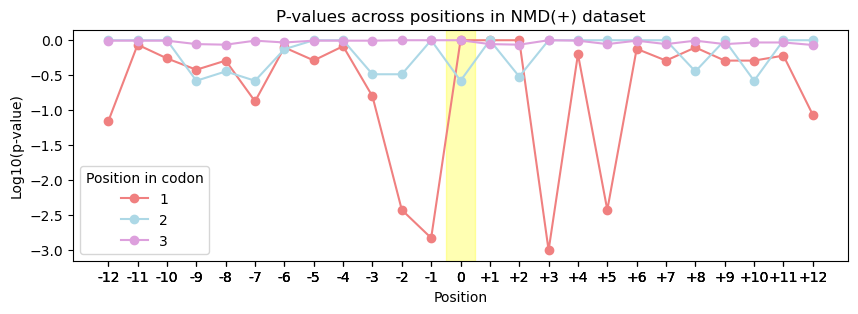

In [87]:
plt.figure(figsize=(10, 3))
#colors = ['#C8A2C8', '#B0E0E6', '#FFB6C1']
colors = ['lightcoral', 'lightblue', 'plum']

for positions, p_values, color in zip(positions_list, p_values_list, colors):
    plt.plot(positions, np.log10(p_values), marker='o', linestyle='-', color=color)

plt.title('P-values across positions in NMD(+) dataset')
plt.xlabel('Position')
plt.ylabel('Log10(p-value)')
plt.grid(False)
plt.legend(['1', '2', '3'], title='Position in codon')

all_positions = [pos for sublist in positions_list for pos in sublist]
plt.xticks(all_positions, [str(pos) if pos == 0 else f"{pos}" if pos < 0 else f"+{pos}" for pos in all_positions])

plt.axvspan(-0.5, 0.5, color='yellow', alpha=0.3)

plt.savefig('images/p_values_nmd_undergo_plot_wo_in_clinvar.png')
plt.show()

In [88]:
# нижние точки это ~ 0.001 и 0.003

## 8. Relationship between the significance of a variant and its position in a codon

In [78]:
pat_nmd_undergo_final.loc[:, 'Significance'] = 'pathogenic'
ben_nmd_undergo_final.loc[:, 'Significance'] = 'benign'

In [79]:
all_nmd_undergo_final = pd.concat([pat_nmd_undergo_final, ben_nmd_undergo_final], ignore_index=True)

In [80]:
all_nmd_undergo_final.to_csv('data/all_nmd_undergo_final_wo_in_clinvar.csv', index=False)

In [81]:
all_nmd_undergo_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_flags,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Significance
0,chr1,180090734,NaN,G,A,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.689116955313235,0.184,0.637977,NO,CGGCAAAGAATTGGAAATCACTAAC,2,TGG,TAG,pathogenic
1,chr1,180093304,NaN,C,A,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.769617276031644,0.184,0.637977,NO,ATTTTGAGGTGTCATCTTTGCTGTC,2,TCA,TAA,pathogenic
2,chr1,179990579,NaN,A,T,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.0206328843275604,0.184,0.656119,NO,GTCATGGATACCAAGAAGTCTTCTA,1,AAG,TAG,pathogenic
3,chr1,180094072,NaN,C,G,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.851721188796237,0.184,0.931839,NO,ACCAGCAGTCTTCAGTGGATTCACA,2,TCA,TGA,pathogenic
4,chr1,179996755,NaN,C,T,1.0,stop_gained,HIGH,CEP350,ENSG00000135837,...,NaN,PERCENTILE:0.0639298695745136,0.184,0.631281,NO,TTTTTAAATGATCGACCAGCAATTG,1,CGA,TGA,pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9517,chr11,61528140,rs368961138,G,A,5.0,stop_gained,HIGH,SYT7,ENSG00000011347,...,NaN,PERCENTILE:0.6045608927705,0.300,0.982997,NO,GAGGGTTGCAGCCGAGAGAACCTGG,1,CGA,TGA,benign
9518,chr11,64767020,NaN,G,A,5.0,stop_gained,HIGH,SF1,ENSG00000168066,...,NaN,PERCENTILE:0.761458333333333,0.177,0.512394,NO,CCTCCCAGTGGGCAGCCCCCACCCC,1,CAG,TAG,benign
9519,chr1,183261240,NaN,G,A,7.0,stop_gained,HIGH,NMNAT2,ENSG00000157064,...,NaN,PERCENTILE:0.773809523809524,0.265,0.955024,NO,GCCGACACAGACCGAATCATGAATC,1,CGA,TGA,benign
9520,chr20,10275537,NaN,C,T,3.0,stop_gained,HIGH,SNAP25,ENSG00000132639,...,NaN,PERCENTILE:0.0740740740740741,0.229,0.763338,NO,GAGGAGATGCAGCGAAGGGCTGACC,1,CGA,TGA,benign


In [82]:
cross_tab_undergo = pd.crosstab(all_nmd_undergo_final['Significance'], all_nmd_undergo_final['Codon_position'])
print(cross_tab_undergo)

Codon_position     1    2    3
Significance                  
benign          3764  492  505
pathogenic      2970  822  969


In [83]:
cross_tab_undergo_perc = pd.crosstab(
    all_nmd_undergo_final['Significance'], 
    all_nmd_undergo_final['Codon_position'], 
    normalize='index'  # Делит на сумму в каждой строке
) * 100
print(cross_tab_undergo_perc)

Codon_position          1          2          3
Significance                                   
benign          79.059021  10.333963  10.607015
pathogenic      62.381853  17.265280  20.352867


In [84]:
chi2_undergo, p_value_undergo, _, _ = chi2_contingency(cross_tab_undergo)
print(f"Chi-squared value: {chi2_undergo}")
print(f"P-value: {p_value_undergo}")

Chi-squared value: 322.5589671453503
P-value: 9.061711684887623e-71


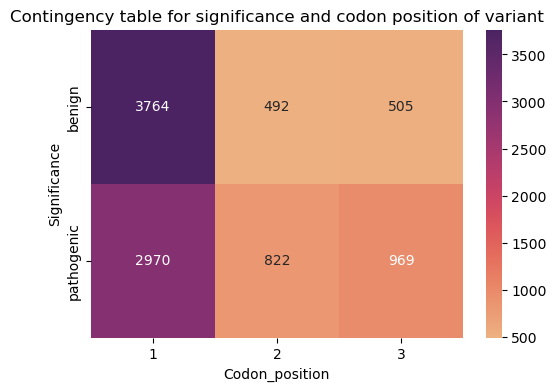

In [85]:
plt.figure(figsize=(6, 4))
sns.heatmap(cross_tab_undergo, annot=True, cmap='flare', fmt='d', cbar=True)
plt.title('Contingency table for significance and codon position of variant')
plt.xlabel('Codon_position')
plt.ylabel('Significance')
plt.show()


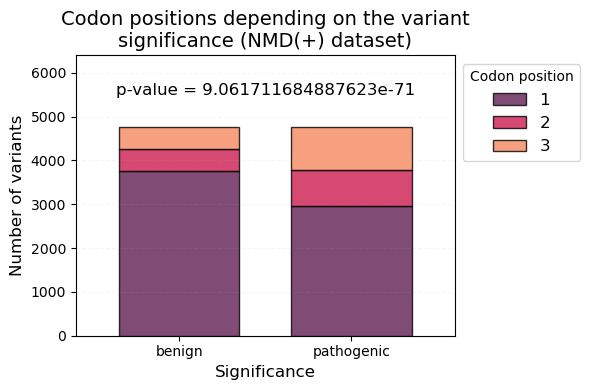

In [89]:
palette = sns.color_palette("rocket", len(cross_tab_undergo.columns))

ax = cross_tab_undergo.plot(kind='bar', stacked=True, alpha=0.8, edgecolor='black', linewidth=1, width=0.7, color=palette, figsize=(6, 4))

plt.title('Codon positions depending on the variant\nsignificance (NMD(+) dataset)', fontsize=14)
plt.xlabel('Significance', fontsize=12)
plt.ylabel('Number of variants', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Codon position', fontsize=12, bbox_to_anchor=(1, 1), loc='upper left')
plt.ylim(top=cross_tab_undergo.max().max() * 1.7)
plt.text(0.5, 5500, f'p-value = {p_value_undergo}', fontsize=12, ha='center')
plt.grid(True, axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()

plt.savefig('images/codon_positions_hist_undergo_wo_in_clinvar.png', dpi=300)

plt.show()